
# Retinal OCT Multi-Class Classification

## COMP6252 - Deep Learning Technology

### Coursework II
Group- Bishal Kumar Pandey, Harshidi R Soni, Md. Ausuf Shaikh, Vasu Bhut


### Imports and Setup



In [1]:
import json
import random
import warnings
from copy import deepcopy
from pathlib import Path
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: NVIDIA GeForce RTX 4070


c:\Users\bkp1n25\Downloads\DL\dltech\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Configuration

In [2]:
SEED = 42
DATA_DIR = Path("data/OCT2017")
OUTPUT_DIR = Path("outputs")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = OUTPUT_DIR / "figures"
REPORT_DIR = OUTPUT_DIR / "reports"

CLASS_NAMES = ["CNV", "DME", "DRUSEN", "NORMAL"]
NUM_CLASSES = len(CLASS_NAMES)
MODEL_IMAGE_SIZES = {
    "custom_cnn": 160,
    "resnet50": 224,
    "efficientnet": 224,
}
BATCH_SIZE = 64
NUM_WORKERS = 0 
VAL_SPLIT = 0.20

EPOCHS = 10
LEARNING_RATE = 1e-3
FINE_TUNE_LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 4
FINE_TUNE_EPOCH = 4
LABEL_SMOOTHING = 0.05
USE_CLASS_WEIGHTS = True
USE_PRETRAINED = True

MODELS_TO_TRAIN = ["custom_cnn", "resnet50", "efficientnet"]
EVALUATE_TEST_DURING_TRAINING = True

for directory in [CHECKPOINT_DIR, FIGURE_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

set_seed(SEED)

### Data Loading



In [3]:
train_dir = DATA_DIR / "train"
val_dir = DATA_DIR / "val"
test_dir = DATA_DIR / "test"

print("Dataset root:", DATA_DIR.resolve())
print("Train folder exists:", train_dir.exists())
print("Validation folder exists:", val_dir.exists())
print("Test folder exists:", test_dir.exists())

def check_class_folders(root: Path, expected_classes: list[str]) -> None:
    found = sorted([path.name for path in root.iterdir() if path.is_dir()])
    missing = [name for name in expected_classes if name not in found]
    if missing:
        raise ValueError(f"Missing class folders in {root}: {missing}. Found: {found}")


check_class_folders(train_dir, CLASS_NAMES)
if test_dir.exists():
    check_class_folders(test_dir, CLASS_NAMES)
if val_dir.exists():
    check_class_folders(val_dir, CLASS_NAMES)

raw_train_dataset = datasets.ImageFolder(train_dir)
print("Classes detected by ImageFolder:", raw_train_dataset.classes)
print("Training images:", len(raw_train_dataset))

Dataset root: C:\Users\bkp1n25\Downloads\DL\data\OCT2017
Train folder exists: True
Validation folder exists: True
Test folder exists: True
Classes detected by ImageFolder: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Training images: 83484


### Data Preprocessing and Augmentation

All models use the same image size and ImageNet normalization. OCT images are converted to three channels so that pretrained ImageNet models can be used. Augmentation is applied only to the training data.


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def get_transforms(image_size: int):
    train_transforms = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((image_size + 32, image_size + 32)),
        transforms.RandomCrop(image_size),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), fill=0),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    eval_transforms = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    return train_transforms, eval_transforms


def denormalize(tensor: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)

### Dataset Visualisation

In [5]:
# Use a default image size for the preview (matches custom_cnn)
_, eval_transforms = get_transforms(MODEL_IMAGE_SIZES["custom_cnn"])
preview_dataset = datasets.ImageFolder(train_dir, transform=eval_transforms)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, index in zip(axes.ravel(), np.linspace(0, len(preview_dataset) - 1, 8, dtype=int)):
    image, label = preview_dataset[index]
    ax.imshow(denormalize(image).permute(1, 2, 0))
    ax.set_title(preview_dataset.classes[label])
    ax.axis("off")
plt.suptitle("Sample Retinal OCT Images")
plt.tight_layout()
plt.show()


NameError: name 'eval_transforms' is not defined

### Class Distribution Analysis


CNV       37205
DME       11348
DRUSEN     8616
NORMAL    26315
Name: count, dtype: int64


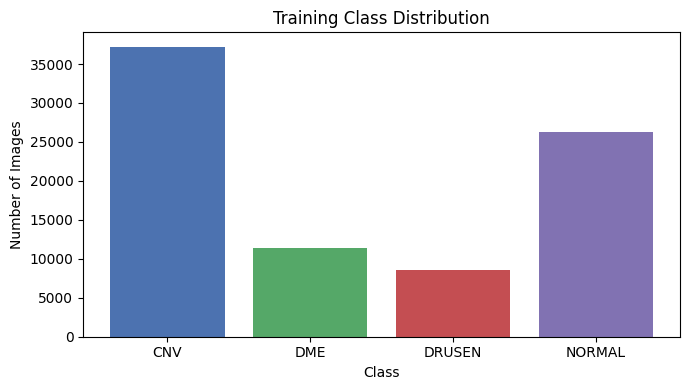

In [ ]:
def count_labels(dataset: datasets.ImageFolder) -> pd.Series:
    labels = [label for _, label in dataset.samples]
    counts = pd.Series(labels).value_counts().sort_index()
    counts.index = [dataset.classes[index] for index in counts.index]
    return counts


train_counts = count_labels(raw_train_dataset)
print(train_counts)

plt.figure(figsize=(7, 4))
plt.bar(train_counts.index, train_counts.values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
plt.title("Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


def compute_class_weights(labels: np.ndarray, num_classes: int) -> torch.Tensor:
    counts = np.bincount(labels, minlength=num_classes).astype(np.float32)
    counts[counts == 0] = 1.0
    weights = counts.sum() / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


### Train/Validation/Test Split


In [ ]:
def make_loader(dataset, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


def build_dataloaders_for_model(model_name: str):
    image_size = MODEL_IMAGE_SIZES[model_name]
    train_transforms, eval_transforms = get_transforms(image_size)

    train_eval_dataset = datasets.ImageFolder(train_dir, transform=eval_transforms)
    train_aug_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)

    labels = np.array(train_eval_dataset.targets)
    indices = np.arange(len(train_eval_dataset))

    splitter = StratifiedShuffleSplit(
        n_splits=1,
        test_size=VAL_SPLIT,
        random_state=SEED,
    )
    train_indices, val_indices = next(splitter.split(indices, labels))

    train_dataset = Subset(train_aug_dataset, train_indices)
    val_dataset = Subset(train_eval_dataset, val_indices)

    train_labels_for_weights = labels[train_indices]

    test_dataset = datasets.ImageFolder(test_dir, transform=eval_transforms) if test_dir.exists() else None

    train_loader = make_loader(train_dataset, BATCH_SIZE, shuffle=True)
    val_loader = make_loader(val_dataset, BATCH_SIZE, shuffle=False)
    test_loader = make_loader(test_dataset, BATCH_SIZE, shuffle=False) if test_dataset is not None else None

    model_class_weights = compute_class_weights(train_labels_for_weights, NUM_CLASSES).to(DEVICE)

    print(f"
{model_name} -> image size: {image_size}")
    print(f"Train samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset) if test_dataset is not None else 0}")

    return train_loader, val_loader, test_loader, model_class_weights

SyntaxError: unexpected character after line continuation character (2777837760.py, line 41)

### Model Definitions

Four models are defined under the same interface. The Custom CNN acts as a baseline trained from scratch. ResNet50 and EfficientNet-B0 use ImageNet-pretrained backbones with replacement classification heads.


CNN


In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.block(x)


class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32, dropout=0.10),
            ConvBlock(32, 64, dropout=0.15),
            ConvBlock(64, 128, dropout=0.20),
            ConvBlock(128, 128, dropout=0.25),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

ResNet


In [ ]:
def freeze_parameters(model: nn.Module) -> None:
    for parameter in model.parameters():
        parameter.requires_grad = False


def build_resnet50(num_classes: int = 4, pretrained: bool = True, freeze_backbone: bool = True) -> nn.Module:
    weights = models.ResNet50_Weights.DEFAULT if pretrained else None
    model = models.resnet50(weights=weights)
    if freeze_backbone:
        freeze_parameters(model)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(512, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model

EfficientNet

In [ ]:
def build_efficientnet(num_classes: int = 4, pretrained: bool = True, freeze_backbone: bool = True) -> nn.Module:
    weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b0(weights=weights)
    if freeze_backbone:
        freeze_parameters(model)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes),
    )
    return model

Model Training

In [ ]:
def build_model(model_name: str) -> nn.Module:
    if model_name == "custom_cnn":
        return CustomCNN(NUM_CLASSES)
    if model_name == "resnet50":
        return build_resnet50(NUM_CLASSES, USE_PRETRAINED, freeze_backbone=True)
    if model_name == "efficientnet":
        return build_efficientnet(NUM_CLASSES, USE_PRETRAINED, freeze_backbone=True)
    
    raise ValueError(f"Unknown model name: {model_name}")


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

### Training Utility Functions

In [ ]:
class EarlyStopping:
    def __init__(self, patience: int = 4):
        self.patience = patience
        self.best_loss = float("inf")
        self.wait = 0

    def step(self, val_loss: float) -> bool:
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.wait = 0
            return False
        self.wait += 1
        return self.wait >= self.patience


def make_loss() -> nn.Module:
    weights = class_weights if USE_CLASS_WEIGHTS else None
    return nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTHING)


def make_optimizer(model: nn.Module, learning_rate: float) -> optim.Optimizer:
    trainable_parameters = [p for p in model.parameters() if p.requires_grad]
    return optim.AdamW(trainable_parameters, lr=learning_rate, weight_decay=WEIGHT_DECAY)


def unfreeze_model(model: nn.Module) -> None:
    for parameter in model.parameters():
        parameter.requires_grad = True


def run_epoch(model, loader, criterion, optimizer=None, description="") -> dict:
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []

    for images, labels_batch in tqdm(loader, desc=description, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels_batch = labels_batch.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels_batch)

            if training:
                loss.backward()
                optimizer.step()

        probabilities = torch.softmax(outputs.detach(), dim=1)
        predictions = probabilities.argmax(dim=1)

        total_loss += loss.item() * labels_batch.size(0)
        all_labels.extend(labels_batch.cpu().numpy())
        all_preds.extend(predictions.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())

    labels_array = np.asarray(all_labels)
    preds_array = np.asarray(all_preds)
    probs_array = np.asarray(all_probs)

    if len(labels_array) == 0 or len(preds_array) == 0:
        raise RuntimeError(
            "run_epoch() processed zero samples. "
            f"len(loader)={len(loader)}. "
            "Check dataset sizes, DataLoader creation, and the for-loop body."
        )

    return {
        "loss": total_loss / len(labels_array),
        "accuracy": accuracy_score(labels_array, preds_array),
        "labels": labels_array,
        "preds": preds_array,
        "probs": probs_array,
    }


def train_model(model_name: str) -> tuple[nn.Module, dict, Path]:
    print(f"\nTraining {model_name}")
    set_seed(SEED)
    model = build_model(model_name).to(DEVICE)
    train_loader, val_loader, test_loader, model_class_weights = build_dataloaders_for_model(model_name)
    print("Trainable parameters:", f"{count_trainable_parameters(model):,}")

    criterion = nn.CrossEntropyLoss(
        weight=model_class_weights if USE_CLASS_WEIGHTS else None,
        label_smoothing=LABEL_SMOOTHING
    )
    optimizer = make_optimizer(model, LEARNING_RATE)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, EPOCHS))
    early_stopping = EarlyStopping(PATIENCE)
    checkpoint_path = CHECKPOINT_DIR / f"{model_name}_best.pth"

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    fine_tuned = False

    for epoch in range(1, EPOCHS + 1):
        if model_name != "custom_cnn" and not fine_tuned and epoch == FINE_TUNE_EPOCH:
            print("Unfreezing backbone for fine-tuning")
            unfreeze_model(model)
            optimizer = make_optimizer(model, FINE_TUNE_LR)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=max(1, EPOCHS - epoch + 1)
            )
            fine_tuned = True
            print("Trainable parameters:", f"{count_trainable_parameters(model):,}")

        train_start = time.time()
        train_result = run_epoch(
            model, train_loader, criterion, optimizer, f"{model_name} epoch {epoch} train"
        )
        train_time = time.time() - train_start

        val_start = time.time()
        val_result = run_epoch(
            model, val_loader, criterion, None, f"{model_name} epoch {epoch} val"
        )
        val_time = time.time() - val_start

        scheduler.step()

        history["train_loss"].append(float(train_result["loss"]))
        history["val_loss"].append(float(val_result["loss"]))
        history["train_acc"].append(float(train_result["accuracy"]))
        history["val_acc"].append(float(val_result["accuracy"]))
        history["lr"].append(float(scheduler.get_last_lr()[0]))

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"train loss {train_result['loss']:.4f} acc {train_result['accuracy']:.4f} | "
            f"val loss {val_result['loss']:.4f} acc {val_result['accuracy']:.4f} | "
            f"train {train_time/60:.2f} min val {val_time/60:.2f} min"
        )

        if val_result["loss"] < best_val_loss:
            best_val_loss = float(val_result["loss"])
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            torch.save(
                {
                    "model_name": model_name,
                    "model_state": best_state,
                    "class_names": CLASS_NAMES,
                    "epoch": epoch,
                    "val_loss": best_val_loss,
                    "val_accuracy": float(val_result["accuracy"]),
                },
                checkpoint_path,
            )

        if early_stopping.step(float(val_result["loss"])):
            print("Early stopping triggered")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"Best validation loss for {model_name}: {best_val_loss:.4f} at epoch {best_epoch}")
    return model, history, checkpoint_path, val_loader, test_loader


### Evaluation Functions

This section computes the metrics required for the coursework: accuracy, precision, recall, F1-score, confusion matrix, classification report, Cohen's kappa, and multiclass AUC-ROC where feasible.


In [ ]:
def calculate_metrics(labels: np.ndarray, preds: np.ndarray, probs: np.ndarray) -> tuple[dict, pd.DataFrame, np.ndarray]:
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    try:
        labels_binary = label_binarize(labels, classes=list(range(NUM_CLASSES)))
        auc_macro = roc_auc_score(labels_binary, probs, average="macro", multi_class="ovr")
    except ValueError:
        auc_macro = None

    summary = {
        "accuracy": accuracy_score(labels, preds),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "cohen_kappa": cohen_kappa_score(labels, preds),
        "auc_roc_macro_ovr": auc_macro,
    }

    report_df = pd.DataFrame(
        classification_report(
            labels,
            preds,
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()

    cm = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    return summary, report_df, cm


def plot_training_history(history: dict, model_name: str) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"], label="Validation")
    axes[0].set_title(f"{model_name} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"], label="Validation")
    axes[1].set_title(f"{model_name} Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm: np.ndarray, title: str) -> None:
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(NUM_CLASSES)
    plt.xticks(ticks, CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(ticks, CLASS_NAMES)

    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            colour = "white" if cm[row, col] > threshold else "black"
            plt.text(col, row, int(cm[row, col]), ha="center", va="center", color=colour)

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


def evaluate_model(model: nn.Module, loader: DataLoader, split_name: str, model_name: str, verbose: bool = False) -> dict:
    criterion = make_loss()
    result = run_epoch(model, loader, criterion, None, f"{model_name} {split_name}")
    summary, report_df, cm = calculate_metrics(result["labels"], result["preds"], result["probs"])

    if verbose:
        print(f"\n{model_name} {split_name} summary")
        display(pd.Series(summary).to_frame("value"))
        display(report_df)
        plot_confusion_matrix(cm, f"{model_name} {split_name} Confusion Matrix")

    return {
        "summary": summary,
        "report": report_df,
        "confusion_matrix": cm,
        "labels": result["labels"],
        "preds": result["preds"],
        "probs": result["probs"],
    }

### Training Each Model



In [ ]:
trained_models = {}
histories = {}
validation_results = {}
test_results = {}
checkpoint_paths = {}

for model_name in MODELS_TO_TRAIN:
    model, history, checkpoint_path, val_loader, test_loader = train_model(model_name)

    trained_models[model_name] = model
    histories[model_name] = history
    checkpoint_paths[model_name] = checkpoint_path

    plot_training_history(history, model_name)

    validation_results[model_name] = evaluate_model(
        model, val_loader, "validation", model_name, verbose=False
    )

    if test_loader is not None:
        test_results[model_name] = evaluate_model(
            model, test_loader, "test", model_name, verbose=False
        )


Training custom_cnn
Trainable parameters: 250,052


KeyboardInterrupt: 

### Comparing Model Results

The model comparison table summarises the main evaluation metrics. 

In [ ]:
comparison_source = test_results if test_results else validation_results
comparison_split = "test" if test_results else "validation"

comparison_rows = []
for model_name, result in comparison_source.items():
    row = {"model": model_name, "split": comparison_split}
    row.update(result["summary"])
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
display(comparison_df)

best_model_name = comparison_df.iloc[0]["model"]
print("Best model:", best_model_name)

best_result = comparison_source[best_model_name]
display(pd.Series(best_result["summary"]).to_frame("value"))
display(best_result["report"])
plot_confusion_matrix(best_result["confusion_matrix"], f"{best_model_name} {comparison_split} Confusion Matrix")

### Error Analysis

Error analysis helps identify which classes are confused and whether mistakes are associated with low model confidence. The best model by macro F1-score is selected for this analysis.


In [ ]:
if len(comparison_df) > 0:
    best_model_name = comparison_df.iloc[0]["model"]
    best_result = comparison_source[best_model_name]
    labels = best_result["labels"]
    preds = best_result["preds"]
    probs = best_result["probs"]

    errors = np.where(labels != preds)[0]
    print("Best model:", best_model_name)
    print("Number of errors:", len(errors))

    error_rows = []
    for index in errors:
        error_rows.append({
            "index": int(index),
            "true_label": CLASS_NAMES[int(labels[index])],
            "predicted_label": CLASS_NAMES[int(preds[index])],
            "confidence": float(probs[index, preds[index]]),
        })

    error_df = pd.DataFrame(error_rows).sort_values("confidence", ascending=False)
    display(error_df.head(20))

    if len(error_df) > 0:
        confusion_pairs = (
            error_df.groupby(["true_label", "predicted_label"])
            .size()
            .reset_index(name="count")
            .sort_values("count", ascending=False)
        )
        display(confusion_pairs)
        confusion_pairs.to_csv(REPORT_DIR / f"{best_model_name}_error_pairs.csv", index=False)
else:
    print("No model results available for error analysis.")


### Inference on a Single Image

This optional cell loads the best model checkpoint and predicts the class of a single OCT image. 

In [ ]:
SINGLE_IMAGE_PATH ="data/OCT2017/test/NORMAL/NORMAL-2705520-1.jpeg"

def predict_single_image(checkpoint_path: Path, image_path: Path) -> pd.DataFrame:
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model_name = checkpoint["model_name"]
    model = build_model(model_name).to(DEVICE)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    image_size = MODEL_IMAGE_SIZES[model_name]
    _, eval_transforms = get_transforms(image_size)
    image = Image.open(image_path).convert("RGB")
    image_tensor = eval_transforms(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probabilities = torch.softmax(model(image_tensor), dim=1).squeeze(0).cpu().numpy()

    prediction_df = pd.DataFrame({"class": CLASS_NAMES, "probability": probabilities})
    return prediction_df.sort_values("probability", ascending=False)


if SINGLE_IMAGE_PATH is not None:
    if len(comparison_df) == 0:
        raise RuntimeError("Train or load a model before running single-image inference.")
    best_model_name = comparison_df.iloc[0]["model"]
    display(predict_single_image(checkpoint_paths[best_model_name], Path(SINGLE_IMAGE_PATH)))
else:
    print("Set SINGLE_IMAGE_PATH to run single-image inference.")


### Conclusion

This notebook provides a unified, reproducible pipeline for retinal OCT classification. The Custom CNN provides a useful baseline, while pretrained transfer-learning models allow stronger feature extraction from limited medical image data. The use of a shared split, shared preprocessing, common metrics, and consistent checkpointing makes the comparison fair.

For the written report, discuss:

- which model achieved the best macro F1-score and why this is clinically more informative than accuracy alone;
- the most common class confusions, especially between visually similar disease classes;
- whether class weighting helped address imbalance;
- evidence of overfitting from the training curves;
- limitations, such as dataset noise, class imbalance, and the need for external validation.
